# Phase 2 — Dataset preparation for PD detection (VSB dataset)

This notebook prepares the VSB data for training a 1D-CNN in PyTorch. It follows stages 1 and 2 of the methodology:

1. **Prepare the data:** load the labels and split them into training, validation and test sets, grouped by measurement.
2. **Clean and compress the signals:** remove the 50 Hz component, denoise with wavelets, and shrink each 800,000-point signal into 160 time steps.
3. **Hand the data to PyTorch:** normalise the features and wrap them in `Dataset` and `DataLoader` objects.

Run the cells from top to bottom.

## 1. Imports and settings

All the adjustable settings live here, so you can change them in one place. `HIGHPASS_CUTOFF` is a starting value you may tune later. `LIMIT` lets you test the pipeline on a few signals before processing all 8,712.

In [1]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import pywt                      # PyWavelets: wavelet denoising
import matplotlib.pyplot as plt
from scipy import signal         # SciPy: high-pass filter
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm       # progress bars

DATA_DIR = '/kaggle/input/competitions/vsb-power-line-fault-detection'
OUT_DIR = '/kaggle/working'

N_SAMPLES = 800_000              # points per signal
DURATION = 0.02                  # seconds, one 50 Hz cycle
FS = N_SAMPLES / DURATION        # sampling rate = 40 MHz
HIGHPASS_CUTOFF = 10_000         # Hz, starting value (tunable)
N_CHUNKS = 160                   # each signal becomes 160 time steps
N_FEATURES = 7                   # summary numbers per chunk
SEED = 42                        # makes the random split repeatable

LIMIT = None                       # test on 60 signals first; set to None for all signals

## 2. Load the labels and check the class imbalance

Each row of the metadata describes one signal: its `signal_id`, the `id_measurement` it belongs to (three phases share one measurement), its `phase`, and its `target` (1 = PD, 0 = no PD).

In [2]:
meta = pd.read_csv(f'{DATA_DIR}/metadata_train.csv')
print(meta.head())
print('Signals:', len(meta), '| Measurements:', meta['id_measurement'].nunique())
print(meta['target'].value_counts())
print(f"Share of signals with PD: {meta['target'].mean():.1%}")

   signal_id  id_measurement  phase  target
0          0               0      0       0
1          1               0      1       0
2          2               0      2       0
3          3               1      0       1
4          4               1      1       1
Signals: 8712 | Measurements: 2904
target
0    8187
1     525
Name: count, dtype: int64
Share of signals with PD: 6.0%


## 3. Split into training, validation and test sets

We split by **measurement**, not by individual signal, so the three phases of one measurement always land in the same set. Otherwise the model could see one phase in training and a near-identical phase in testing, which would inflate the test score.

A measurement counts as PD if any of its phases has PD. `stratify` keeps the PD share roughly equal across the three sets. The split is 70% training, 15% validation and 15% test.

In [3]:
meas = meta.groupby('id_measurement')['target'].max().reset_index()

train_ids, temp_ids = train_test_split(
    meas['id_measurement'], test_size=0.30,
    stratify=meas['target'], random_state=SEED)

temp = meas[meas['id_measurement'].isin(temp_ids)]
val_ids, test_ids = train_test_split(
    temp['id_measurement'], test_size=0.50,
    stratify=temp['target'], random_state=SEED)

split_map = {**{m: 'train' for m in train_ids},
             **{m: 'val' for m in val_ids},
             **{m: 'test' for m in test_ids}}
meta['split'] = meta['id_measurement'].map(split_map)

# Safety checks: every signal has a split, and no measurement is in two splits
assert meta['split'].notna().all()
assert meta.groupby('id_measurement')['split'].nunique().max() == 1

print(meta.groupby('split')['target'].agg(count='count', pd_share='mean'))

       count  pd_share
split                 
test    1308  0.055810
train   6096  0.061188
val     1308  0.060398


## 4. Preprocessing functions

Each raw signal goes through three steps:

- **`highpass`** removes the slow 50 Hz grid wave using a zero-phase Butterworth filter. Zero-phase filtering (`sosfiltfilt`) runs the filter forwards and backwards, so pulse positions are not shifted in time.
- **`wavelet_denoise`** splits the signal into frequency layers, estimates the background noise level, and removes small coefficients below a threshold. Sharp PD pulses are strong enough to survive; background noise is mostly removed.
- **`compress`** cuts the 800,000 points into 160 chunks of 5,000 points and describes each chunk with 7 numbers: mean, standard deviation, minimum, maximum, range (max − min), and the 1st and 99th percentiles.

In [4]:
SOS = signal.butter(5, HIGHPASS_CUTOFF, btype='highpass', fs=FS, output='sos')

def highpass(x):
    return signal.sosfiltfilt(SOS, x)

def wavelet_denoise(x, wavelet='db4', level=1):
    coeffs = pywt.wavedec(x, wavelet, mode='per', level=level)
    # Estimate the noise level from the finest detail layer (median absolute deviation)
    sigma = np.median(np.abs(coeffs[-1] - np.median(coeffs[-1]))) / 0.6745
    threshold = sigma * np.sqrt(2 * np.log(len(x)))   # 'universal' threshold
    coeffs[1:] = [pywt.threshold(c, value=threshold, mode='hard') for c in coeffs[1:]]
    return pywt.waverec(coeffs, wavelet, mode='per')[:len(x)]

def compress(x, n_chunks=N_CHUNKS):
    chunks = x.reshape(n_chunks, -1)          # shape (160, 5000)
    feats = [chunks.mean(1), chunks.std(1), chunks.min(1), chunks.max(1),
             chunks.max(1) - chunks.min(1),
             np.percentile(chunks, 1, axis=1), np.percentile(chunks, 99, axis=1)]
    return np.stack(feats, axis=1).astype(np.float32)   # shape (160, 7)

def preprocess(raw):
    x = raw.astype(np.float32)
    x = highpass(x)
    x = wavelet_denoise(x)
    return compress(x)

## 5. Visual check on one PD signal

Before processing everything, check that each step does what we expect. The filtered signal should be centred on zero with the sine wave gone, and the denoised signal should keep the large pulses while flattening the background.

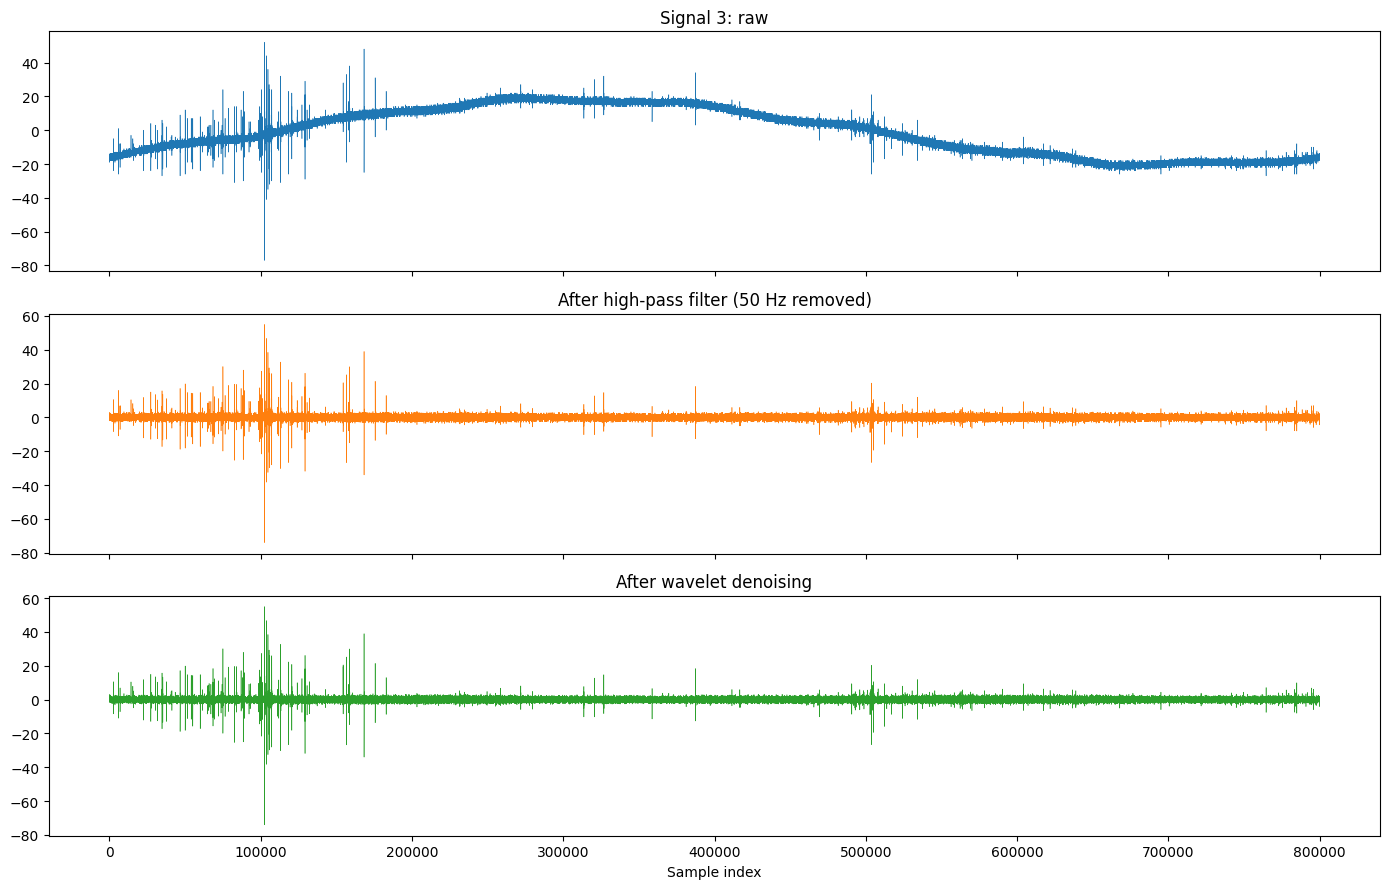

In [5]:
sid = meta.loc[meta['target'] == 1, 'signal_id'].iloc[0]
raw = pq.read_table(f'{DATA_DIR}/train.parquet', columns=[str(sid)]).column(0).to_numpy()
hp = highpass(raw.astype(np.float32))
dn = wavelet_denoise(hp)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
axes[0].plot(raw, linewidth=0.4); axes[0].set_title(f'Signal {sid}: raw')
axes[1].plot(hp, linewidth=0.4, color='tab:orange'); axes[1].set_title('After high-pass filter (50 Hz removed)')
axes[2].plot(dn, linewidth=0.4, color='tab:green'); axes[2].set_title('After wavelet denoising')
axes[2].set_xlabel('Sample index')
plt.tight_layout(); plt.show()

## 6. Process the signals and save the result

Signals are read from the parquet file in batches of 300 to keep memory use low. With `LIMIT = 60`, this runs in seconds as a test. Once it works, set `LIMIT = None` in cell 1, re-run cell 1, then run this cell again to process all 8,712 signals. The full run takes roughly 10–30 minutes.

The output is a NumPy array `X` of shape (number of signals, 160, 7), saved together with the metadata.

In [6]:
run_meta = meta.iloc[:LIMIT] if LIMIT else meta
signal_ids = run_meta['signal_id'].values
X = np.zeros((len(signal_ids), N_CHUNKS, N_FEATURES), dtype=np.float32)

BATCH = 300
for start in tqdm(range(0, len(signal_ids), BATCH)):
    batch_ids = signal_ids[start:start + BATCH]
    table = pq.read_table(f'{DATA_DIR}/train.parquet', columns=[str(s) for s in batch_ids])
    for j, s in enumerate(batch_ids):
        X[start + j] = preprocess(table.column(str(s)).to_numpy())
    del table

np.save(f'{OUT_DIR}/X_processed.npy', X)
run_meta.to_csv(f'{OUT_DIR}/meta_with_split.csv', index=False)
print('Saved X with shape', X.shape)

  0%|          | 0/30 [00:00<?, ?it/s]

Saved X with shape (8712, 160, 7)


## 7. Normalise the features

The 7 features have very different scales, which makes training harder. We rescale each feature to roughly mean 0 and standard deviation 1.

The mean and standard deviation are calculated from the **training set only**, then applied to all three sets. Using validation or test data here would leak information about them into training.

In [7]:
split = run_meta['split'].values
y = run_meta['target'].values

train_mask = split == 'train'
feat_mean = X[train_mask].mean(axis=(0, 1))
feat_std = X[train_mask].std(axis=(0, 1)) + 1e-6     # small number avoids dividing by zero
X_norm = (X - feat_mean) / feat_std

np.savez(f'{OUT_DIR}/norm_stats.npz', mean=feat_mean, std=feat_std)
print('Feature means after normalising (train):', X_norm[train_mask].mean(axis=(0, 1)).round(2))

Feature means after normalising (train): [-0. -0.  0. -0.  0.  0. -0.]


## 8. Wrap the data for PyTorch

PyTorch reads training data through two objects:

- A **`Dataset`** answers two questions: how many samples are there, and what is sample number *i*?
- A **`DataLoader`** feeds the samples to the model in small batches, shuffling the training set each epoch.

PyTorch's 1D convolution layers expect data shaped as (batch, channels, length). Our 7 features become the channels and the 160 time steps become the length, so each sample is reshaped from (160, 7) to (7, 160).

In [8]:
import torch
from torch.utils.data import Dataset, DataLoader

class PDDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)   # (N, 7, 160)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

datasets = {s: PDDataset(X_norm[split == s], y[split == s]) for s in ['train', 'val', 'test']}

train_loader = DataLoader(datasets['train'], batch_size=64, shuffle=True)
val_loader = DataLoader(datasets['val'], batch_size=256)
test_loader = DataLoader(datasets['test'], batch_size=256)

for s, d in datasets.items():
    print(f'{s}: {len(d)} signals')

xb, yb = next(iter(train_loader))
print('One training batch:', xb.shape, yb.shape)   # expect [64, 7, 160] and [64]

train: 6096 signals
val: 1308 signals
test: 1308 signals
One training batch: torch.Size([64, 7, 160]) torch.Size([64])


## Next step

With `LIMIT = None` and all cells run, save the notebook with **Save Version > Save & Run All (Commit)**. The processed files (`X_processed.npy`, `meta_with_split.csv`, `norm_stats.npz`) then appear in the notebook's **Output** tab and can be reused in the training notebook without reprocessing.

Next: build and train the 1D-CNN.